In [5]:
!pip install -q rasterio transformers accelerate scikit-learn evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.8 MB/s eta 0:00:00


In [2]:
import os
import shutil
import random
import numpy as np
import rasterio
import torch
import subprocess
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, jaccard_score
from torch.utils.data import Dataset
from transformers import (
    SegformerImageProcessor,
    SegformerForSemanticSegmentation,
    TrainingArguments,
    Trainer
)

# --- Experiment Configuration ---
class Config:
    EXPERIMENT_NAME = "segformer_b0_turkey_wildfire"

    # Dataset Sources
    LOCAL_ZIP_PATH = Path("./TurkeyWildfire.zip")
    DATASET_URL = "https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/hgctmx9y6c-1.zip"

    # We will consolidate data here for the model to use
    EXTRACT_DIR = Path("./wildfire_data")

    # Data Processing
    CLIP_VALUE = 5000.0
    IMAGE_SIZE = (128, 128)
    TEST_SPLIT = 0.2

    # Model Architecture
    MODEL_CHECKPOINT = "nvidia/mit-b0"
    NUM_LABELS = 2
    ID2LABEL = {0: "Background", 1: "Wildfire"}
    LABEL2ID = {"Background": 0, "Wildfire": 1}

    # Training Hyperparameters
    BATCH_SIZE = 16
    LEARNING_RATE = 6e-5
    EPOCHS = 10
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

print(f"⚙️ Configuration loaded for: {Config.EXPERIMENT_NAME}")
print(f"🔧 Device: {Config.DEVICE}")

⚙️ Configuration loaded for: segformer_b0_turkey_wildfire
🔧 Device: cuda


In [3]:
import shutil
import urllib.request
from pathlib import Path

class DataManager:
    """
    Handles data extraction.
    Logic: Check Exists > Download (wget or python fallback) > Unzip > Unrar > Move Folders.
    """
    @staticmethod
    def _check_system_deps():
        """Checks for 'unrar'."""
        if shutil.which("unrar") is None:
            print("⚠️ 'unrar' not found. Attempting to install...")
            if os.path.exists("/content"):
                os.system("apt-get -q install unrar > /dev/null")
            else:
                # On local, we can't easily auto-install unrar, so we warn the user.
                print("❌ 'unrar' is missing on your local machine!")
                print("   Please install WinRAR (Windows) or 'brew install unrar' (Mac).")
                raise SystemError("Unrar tool missing.")

    @staticmethod
    def _get_zip_source():
        """
        Checks if TurkeyWildfire.zip exists.
        If yes -> Returns path (Skips download).
        If no -> Downloads via wget (or Python fallback).
        """
        # --- 1. CHECK IF FILE ALREADY EXISTS ---
        if Config.LOCAL_ZIP_PATH.exists():
            print(f"✅ Found local dataset: {Config.LOCAL_ZIP_PATH}")
            print("   (Skipping download)")
            return Config.LOCAL_ZIP_PATH

        # --- 2. DOWNLOAD IF MISSING ---
        print(f"⬇️ Dataset not found. Downloading...")
        url = Config.DATASET_URL
        destination = str(Config.LOCAL_ZIP_PATH)

        # Try using wget (preferred for Colab/Linux)
        if shutil.which("wget"):
            print("   Using: System wget")
            exit_code = os.system(f"wget -O {destination} -q {url}")
            if exit_code != 0:
                raise RuntimeError("❌ wget download failed.")
        else:
            # Fallback for Windows/Local machines without wget
            print("   Using: Python urllib (wget not found)")
            try:
                urllib.request.urlretrieve(url, destination)
            except Exception as e:
                raise RuntimeError(f"❌ Python download failed: {e}")

        if not Config.LOCAL_ZIP_PATH.exists():
            raise RuntimeError("❌ Download appeared to succeed but file is missing.")

        print(f"✅ Download complete: {Config.LOCAL_ZIP_PATH}")
        return Config.LOCAL_ZIP_PATH

    @classmethod
    def setup_dataset(cls):
        # 1. Check if data folders already exist (Skip everything if ready)
        if (Config.EXTRACT_DIR / "images").exists() and (Config.EXTRACT_DIR / "masks").exists():
            print(f"✅ Data already prepared in {Config.EXTRACT_DIR}")
            return

        cls._check_system_deps()

        # 2. Get Zip (Checks existence inside here)
        zip_source = cls._get_zip_source()

        # 3. Prepare Work Directory
        work_dir = Path("./temp_work")
        if work_dir.exists(): shutil.rmtree(work_dir)
        work_dir.mkdir(parents=True, exist_ok=True)
        Config.EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

        # 4. Extract Outer Zip
        print(f"📦 Unzipping {zip_source.name}...")
        import zipfile
        with zipfile.ZipFile(zip_source, 'r') as zip_ref:
            zip_ref.extractall(work_dir)

        # 5. Extract Inner RAR
        long_folder_name = "Deep Learning and Remote Sensing Dataset For Turkeys Wildfire 2021 Multispectral Sentinel-2 Satellite Imagery"
        rar_file = work_dir / long_folder_name / "Dataset.rar"

        # Fallback using recursive search if the specific path isn't found
        if not rar_file.exists():
            print(f"⚠️ Specific path '{long_folder_name}' not found, searching recursively...")
            rar_file = next(work_dir.rglob("Dataset.rar"), None)

        if not rar_file:
            raise FileNotFoundError("❌ 'Dataset.rar' not found inside the downloaded zip.")

        print("📦 Extracting Dataset.rar...")
        # 'unrar' command is strictly required here.
        exit_code = os.system(f"unrar x -inul -o+ \"{rar_file}\" \"{work_dir}/\"")

        # 6. Move specific folders
        src_root = work_dir / "Dataset"
        src_images = src_root / "Train Images"
        src_masks = src_root / "Train Masks"

        if not src_images.exists() or not src_masks.exists():
            print(f"❌ Structure mismatch. Found: {[p.name for p in src_root.glob('*')]}")
            raise FileNotFoundError("Could not find 'Train Images' or 'Train Masks'.")

        print("📂 Mapping folders to 'images' and 'masks'...")
        shutil.move(str(src_images), str(Config.EXTRACT_DIR / "images"))
        shutil.move(str(src_masks), str(Config.EXTRACT_DIR / "masks"))

        # Cleanup
        shutil.rmtree(work_dir)
        print(f"✅ Data setup complete. Ready for training.")

# Trigger Setup
DataManager.setup_dataset()

⬇️ Dataset not found. Downloading...
   Using: System wget
✅ Download complete: TurkeyWildfire.zip
📦 Unzipping TurkeyWildfire.zip...
📦 Extracting Dataset.rar...
📂 Mapping folders to 'images' and 'masks'...
✅ Data setup complete. Ready for training.


In [4]:
class TurkeyWildfireDataset(Dataset):
    """
    Custom dataset for Turkey Wildfire data (16-bit TIFs).
    """
    def __init__(self, image_paths, mask_paths, processor, config):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.processor = processor
        self.config = config

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 1. Load Image
        with rasterio.open(self.image_paths[idx]) as src:
            image = src.read() # shape: (Channels, Height, Width)

        # 2. Load Mask
        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1) # shape: (Height, Width)

        # 3. Custom Normalization (Preserved logic from original)
        # Images are 16-bit, clipped to 5000, then normalized to [0, 1]
        image = np.clip(image, 0, self.config.CLIP_VALUE) / self.config.CLIP_VALUE

        # 4. Format Fix: Move axis for Processor (C,H,W -> H,W,C)
        # Transformers library expects channels last for input
        image = np.moveaxis(image, 0, -1).astype(np.float32)

        # 5. Processor
        encoded_inputs = self.processor(
            images=image,
            segmentation_maps=mask,
            return_tensors="pt",
            do_resize=False, # Data is pre-cropped/sized
            do_rescale=False,
            do_normalize=True
        )

        return {
            "pixel_values": encoded_inputs.pixel_values.squeeze(),
            "labels": encoded_inputs.labels.squeeze().long()
        }

def prepare_splits(config):
    """Synchronizes files and performs train/val split."""
    img_dir = config.EXTRACT_DIR / "images"
    msk_dir = config.EXTRACT_DIR / "masks"

    # Robust matching (case insensitive extension check)
    img_files = {p.stem: p for p in img_dir.glob("*") if p.suffix.lower() in ['.tif', '.tiff']}
    msk_files = {p.stem: p for p in msk_dir.glob("*") if p.suffix.lower() in ['.tif', '.tiff']}

    # Intersect to ensure we only use matched pairs
    common = sorted(set(img_files.keys()) & set(msk_files.keys()))
    print(f"📊 Found {len(common)} paired samples.")

    if len(common) == 0:
        raise ValueError("No matching image/mask pairs found! Check your data directory.")

    all_imgs = [img_files[k] for k in common]
    all_msks = [msk_files[k] for k in common]

    # Split
    return train_test_split(all_imgs, all_msks, test_size=config.TEST_SPLIT, random_state=config.SEED)

In [6]:
import evaluate
import torch
import numpy as np

# Load metric once
metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    """
    Standardized metrics for all Wildfire experiments.
    Reports: Mean IoU, Per-Class Accuracy, and 'Fire' class IoU.
    """
    logits, labels = eval_pred

    # Convert logits to predictions
    # Note: Segformer output is usually (Batch, Channels, H, W)
    logits_tensor = torch.from_numpy(logits)

    # Resize logits to match labels if necessary (Segformer outputs 1/4 res usually)
    if logits_tensor.shape[-2:] != labels.shape[-2:]:
        logits_tensor = torch.nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    predictions = logits_tensor.argmax(dim=1).numpy()

    # Calculate metrics
    metrics = metric.compute(
        predictions=predictions,
        references=labels,
        num_labels=2,
        ignore_index=255, # Standard ignore index for boundaries/padding
        reduce_labels=False,
    )

    # Extract the specific "Fire" IoU (assuming class 1 is Fire)
    # This is the single most important number for your advisor.
    fire_iou = metrics["per_category_iou"][1] if len(metrics["per_category_iou"]) > 1 else 0.0

    return {
        "mean_iou": metrics["mean_iou"],
        "mean_accuracy": metrics["mean_accuracy"],
        "fire_iou": fire_iou, # The money metric
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
# 1. Prepare Data Splits
train_imgs, val_imgs, train_msks, val_msks = prepare_splits(Config)

# 2. Initialize Processor & Model
print(f"🚀 Loading model: {Config.MODEL_CHECKPOINT}")
processor = SegformerImageProcessor.from_pretrained(
    Config.MODEL_CHECKPOINT,
    do_resize=False,
    do_rescale=False,
    do_normalize=True
)

# Instantiate Datasets
train_ds = TurkeyWildfireDataset(train_imgs, train_msks, processor, Config)
val_ds = TurkeyWildfireDataset(val_imgs, val_msks, processor, Config)

print(f"📂 Train Size: {len(train_ds)} | Val Size: {len(val_ds)}")

model = SegformerForSemanticSegmentation.from_pretrained(
    Config.MODEL_CHECKPOINT,
    num_labels=Config.NUM_LABELS,
    id2label=Config.ID2LABEL,
    label2id=Config.LABEL2ID,
    ignore_mismatched_sizes=True
)

# 3. Define Training Arguments
args = TrainingArguments(
    output_dir=f"./results/{Config.EXPERIMENT_NAME}",
    learning_rate=Config.LEARNING_RATE,
    num_train_epochs=Config.EPOCHS,
    per_device_train_batch_size=Config.BATCH_SIZE,
    per_device_eval_batch_size=Config.BATCH_SIZE,
    save_strategy="epoch",
    eval_strategy="epoch",
    save_total_limit=2,
    logging_steps=50,
    fp16=(Config.DEVICE == "cuda"),
    remove_unused_columns=False,
    report_to="none",
    dataloader_num_workers=2
)

# 4. Initialize Trainer
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# 5. Start Training
print(f"🔥 Starting training on {Config.DEVICE}...")
trainer.train()

# 6. Save Final Model
save_path = f"./models/{Config.EXPERIMENT_NAME}"
trainer.save_model(save_path)
processor.save_pretrained(save_path)
print(f"🏆 Training finished. Model saved to {save_path}")

📊 Found 25563 paired samples.
🚀 Loading model: nvidia/mit-b0


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


📂 Train Size: 20450 | Val Size: 5113


config.json: 0.00B [00:00, ?B/s]

...

🔥 Starting training on cuda...


model.safetensors:   0%|          | 0.00/14.3M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Mean Iou,Mean Accuracy,Fire Iou
1,0.099600,0.091009,0.862780,0.918340,0.769665
2,0.093800,0.086089,0.867065,0.919378,0.776559
3,0.088400,0.083425,0.870187,0.922373,0.781850
4,0.086100,0.081514,0.873278,0.927643,0.787340
5,0.091700,0.080583,0.872704,0.921232,0.785723
6,0.084200,0.079153,0.876081,0.928963,0.791934
7,0.083200,0.078516,0.876705,0.928692,0.792898
8,0.083500,0.078236,0.876130,0.925248,0.791615
9,0.082200,0.077803,0.877798,0.930399,0.794818
10,0.082500,0.077660,0.877354,0.928170,0.793877


/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/usr/local/lib/python3.12/dist-packages/datasets/features/image.py:357: UserWarning: Downcasting array dtype int64 to int32 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible 

🏆 Training finished. Model saved to ./models/segformer_b0_turkey_wildfire


🧐 Inspecting Test Sample #204...


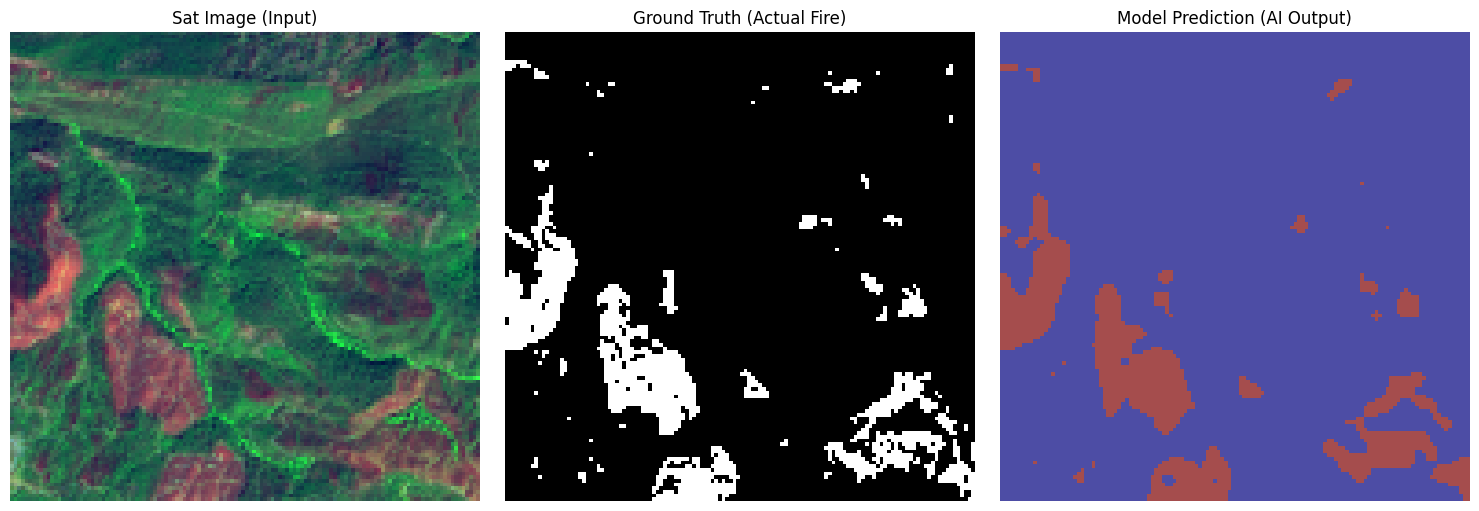

🧐 Inspecting Test Sample #2253...


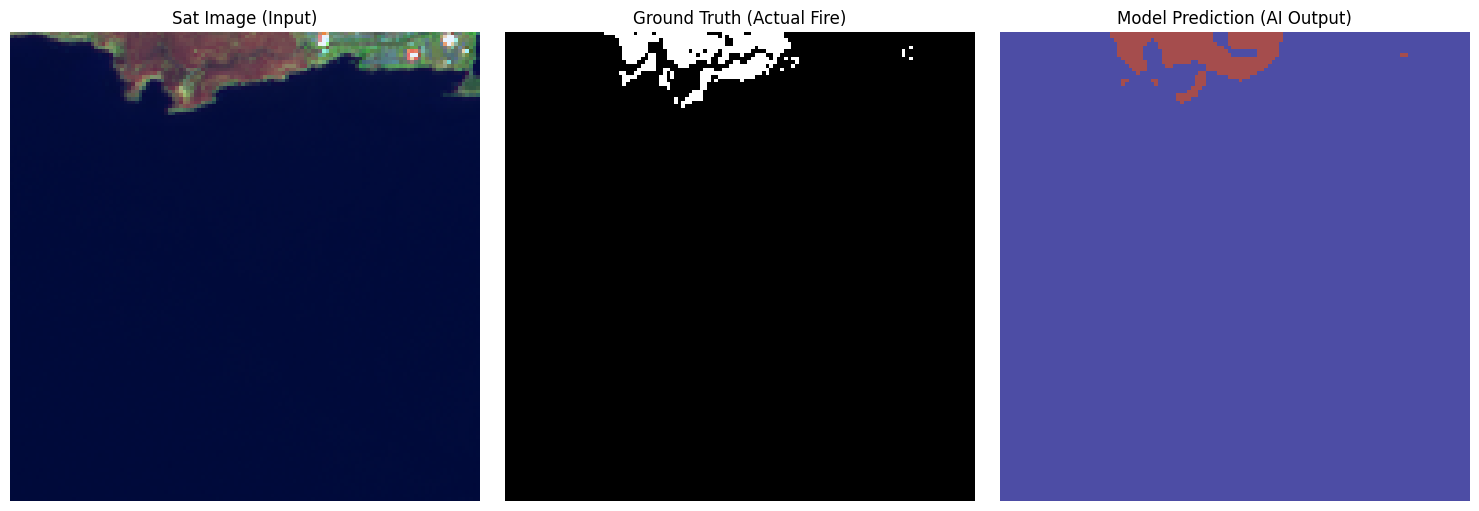

🧐 Inspecting Test Sample #2006...


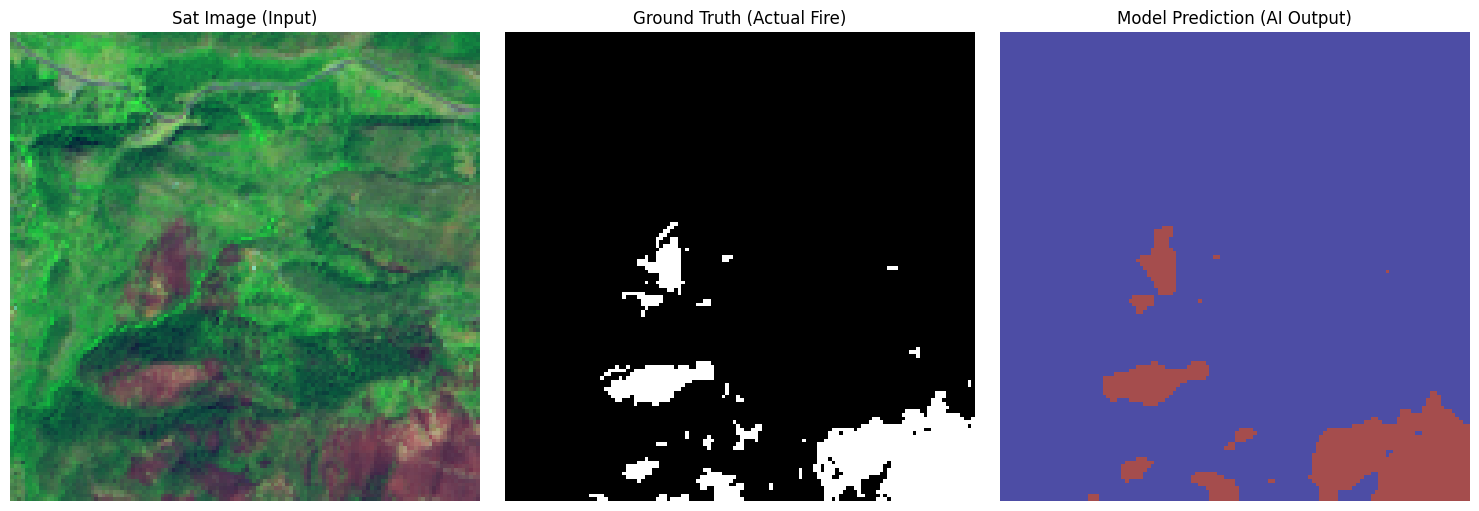

In [9]:
# --- Visual Test & Inspection Cell ---
import matplotlib.pyplot as plt
import torch
import numpy as np
import random

# 1. Define Test Set (Using Validation set for Baseline Phase)
test_ds = val_ds

def visualize_prediction(dataset, model, index=None):
    """
    Visualizes: Input Image | Ground Truth Mask | Predicted Mask
    """
    # Pick a random image if no index provided
    if index is None:
        index = random.randint(0, len(dataset)-1)

    print(f"🧐 Inspecting Test Sample #{index}...")

    # Load Data
    sample = dataset[index]
    image = sample['pixel_values']
    label = sample['labels']

    # Run Inference
    model.eval()
    model.to(Config.DEVICE)
    with torch.no_grad():
        # Add batch dimension (C, H, W) -> (1, C, H, W)
        input_tensor = image.unsqueeze(0).to(Config.DEVICE)
        outputs = model(pixel_values=input_tensor)

        # Upsample logits to original size (SegFormer output is 1/4th size)
        logits = torch.nn.functional.interpolate(
            outputs.logits,
            size=label.shape[-2:], # Match Ground Truth H,W
            mode="bilinear",
            align_corners=False
        )

        # Get Prediction (Argmax)
        pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Prepare for Plotting
    # Image: (C, H, W) -> (H, W, C) & Denormalize for display
    img_display = image.permute(1, 2, 0).numpy()

    # Normalize image to 0-1 range for matplotlib if it isn't already
    img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # 1. Original Image
    axes[0].imshow(img_display)
    axes[0].set_title("Sat Image (Input)")
    axes[0].axis("off")

    # 2. Ground Truth
    axes[1].imshow(label, cmap="gray", interpolation="nearest")
    axes[1].set_title("Ground Truth (Actual Fire)")
    axes[1].axis("off")

    # 3. Prediction
    axes[2].imshow(pred_mask, cmap="jet", alpha=0.7, interpolation="nearest")
    axes[2].set_title("Model Prediction (AI Output)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

# --- Run Visualization ---
# Run this multiple times to see different "Test" examples
for i in range(3):
    visualize_prediction(test_ds, model)

In [10]:
# --- Save Model to Google Drive ---
import os
import shutil
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
# This uses your existing Config class to find the local model
local_model_path = f"./models/{Config.EXPERIMENT_NAME}"

# Define where you want it on Drive
# It will create a folder "Satellite_Project_Models" if it doesn't exist
drive_dest_path = f"/content/drive/MyDrive/Satellite_Project_Models/{Config.EXPERIMENT_NAME}"

# 3. Copy the Model
if os.path.exists(local_model_path):
    print(f"\n🚀 Copying model from {local_model_path} to {drive_dest_path}...")

    # If a version already exists on Drive, remove it to ensure we save the latest
    if os.path.exists(drive_dest_path):
        print("   (Overwriting existing version on Drive...)")
        shutil.rmtree(drive_dest_path)

    # Copy the directory
    shutil.copytree(local_model_path, drive_dest_path)
    print("✅ Success! Model safely saved to Google Drive.")
else:
    print(f"❌ Error: Could not find local model at {local_model_path}. Did the training finish?")

Mounted at /content/drive

🚀 Copying model from ./models/segformer_b0_turkey_wildfire to /content/drive/MyDrive/Satellite_Project_Models/segformer_b0_turkey_wildfire...
✅ Success! Model safely saved to Google Drive.
